# Bearing diagnosis tutorial

In [ ]:
## Do not edit this cell
await __import__("piplite").install('openconmo', deps=False)

import numpy as np
import scipy
import tqdm
import matplotlib.pyplot as plt

from tests import check_all_frequencies
from tests import check_envelope_function

# Bearing Characteristic Frequency Guide

Bearing fault frequencies are the characteristic frequencies of any rolling element bearing which are used to identify local bearing damage. Diagnosis of bearing system begins by calculating these frequencies before analysis.

<figure style="text-align: center;">
  <img src="figures/fault_frequencies_figure.png" alt="Bearing faults">
  <figcaption>Bearing faults with corresponding time domain vibration responses [1].</figcaption>
</figure>

---

The following diagrams illustrate the bearing components and dimensions used in the formulas.


<div style="display: flex; align-items: flex-start; justify-content: space-between; gap: 10px;">

<div style="flex: 1; text-align: center; min-width: 500px;">
  <img src="figures/bearing.png" alt="Bearing faults" height="400">
  <p>Figure 1: Bearing elements.</p>
</div>

<div style="flex: 3; min-width: 400px;">

<p>Table 1: Bearing Fault Frequency Formulas<p>

| Fault Frequency Name | Formula |
| :--- |  :--- |
| **Ball pass frequency, outer race** | $BPFO = \frac{nf_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$ |
| **Ball pass frequency, inner race** | $BPFI = \frac{nf_r}{2} \left( 1 + \frac{d}{D} \cos \phi \right)$ |
| **Fundamental train frequency** | $FTF = \frac{f_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$ |
| **Ball (roller) spin frequency**  | $BSF = \frac{Df_r}{2d} \left( 1 - \left[ \frac{d}{D} \cos \phi \right]^2 \right)$ |

## Variable Definitions
* $n$ = Number of rolling elements
* $f_r$ = Shaft rotation frequency
* $d$ = Rolling element diameter
* $D$ = Bearing pitch diameter
* $\phi$ = Angle of the load from the radial plane
</div>

</div>

---

## Task 1. Calculate bearing fault frequencies for a bearing 6205-2RS JEM SKF 
## Bearing Specifications

The table below details the specifications for a specific bearing model.

| Specification | **6205-2RS JEM SKF (Drive-End Bearing)** |
| :--- | :--- |
| Inside diameter [mm] | 25.0 |
| Outside diameter [mm] | 52.0 |
| Pitch diameter [mm] | 39.0 |
| Ball diameter [mm] | 7.94 |
| Thickness [mm] | 15.0 |
| Number of balls | 9 |
| Contact angle [degrees] | 3.134 |

In [2]:
'''Calculate the bearing characteristic fault frequencies'''
f_r = 1725 / 60
n = 9
d = 7.94e-3
D = 39e-3
phi = 3.134 / 180 * np.pi

BPFO_Hz = (n * f_r / 2) * (1 - (d / D) * np.cos(phi))
BPFI_Hz = (n * f_r / 2) * (1 + (d / D) * np.cos(phi))
FTF_Hz  = (f_r / 2)      * (1 - (d / D) * np.cos(phi))
BSF_Hz  = (D * f_r / (2*d)) * (1 - ((d / D) * np.cos(phi))**2)


# Runs automatic tests to check if the calculated frequencies are correct.
for feedback in check_all_frequencies(BPFO_Hz, BPFI_Hz, FTF_Hz, BSF_Hz, n, d, D, phi, f_r):
    print(feedback)

✅ BPFO_Hz looks correct.
✅ BPFI_Hz looks correct.
✅ FTF_Hz looks correct.
✅ BSF_Hz looks correct.


## Envelope Spectrum
Bearing faults occur as impulses in vibration measurements. Because impulses are not well defined using sinusoids it is best practice to use the envelopes.

Envelope of any signal can be calculated using the [Hilbert transform](https://en.wikipedia.org/wiki/Analytic_signal). Essentially the impulsive time history signal is transformed into smooth signal which resembles a sinusoidal function with frequency related to the fault frequencies. Then with spectral analysis the fault frequencies can be identified.

The single most powerful tool for bearing fault diagnosis is the envelope spectrum. Below is shown step by step how the squared envelope spectrum can be computed. 
***
**Input:** Signal $\mathbf{x}$, sampling frequency $f_s$  
**Output:** Frequency vector $\mathbf{f}$, envelope spectrum $\mathbf{X}$  

1. $\mathbf{a} \leftarrow \text{Hilbert}(\mathbf{x})$ $\;\;\quad\;\qquad \triangleright$ Form the analytic signal  
2. $\mathbf{e} \leftarrow |\mathbf{a}|$ $\;\quad\qquad\qquad\qquad \triangleright$ Compute the envelope  
3. $\mathbf{e}_{\text{sq}} \leftarrow \mathbf{e}^2$ $\;\;\qquad\qquad\qquad \triangleright$ Compute the squared envelope signal  
4. $\mathbf{X} \leftarrow \text{FFT}(\mathbf{e}_{\text{sq}})$ $\;\;\;\quad\quad\quad \triangleright$ Compute the FFT  

**Return** $\mathbf{f}$, $\mathbf{X}$
***

## Task 2: Implement the Envelope algorithm

In [3]:
# You can use these hilbert and fft functions
from scipy.signal import hilbert
from numpy.fft import fft

def envelope(x, fs):
    """
    Parameters
    ----------
    x : ndarray
        The input raw signal.
    fs : float
        The sampling frequency of the input signal.
    Returns
    -------
    X : ndarray
        Amplitude of the squared envelope spectrum.
    """
    
    ## Your code begins here. Expected amount of code: 4-6 lines
    analytic_signal = scipy.signal.hilbert(x)
    envelope = np.abs(analytic_signal)
    squared_envelope = envelope ** 2
    X = fft(squared_envelope)
    ## Your code ends here
    
    # Calculates the frequencies corresponding to the FFT spectrum
    N = len(x)
    X = np.abs(X[:N//2]) * (2 / N)
    f = np.linspace(0, fs / 2, N // 2)
    
    return f, X # function should return the frequencies and the squared envelope spectrum

print(check_envelope_function(envelope))

✅ envelope() looks correct.


# Task 3: Plot the envelope spectrum
Perform the envelope analysis for the given vibration data. Plot the envelope spectrum for the vibration data and identify the fault frequency.

Text(0.5, 0, 'Time (samples)')

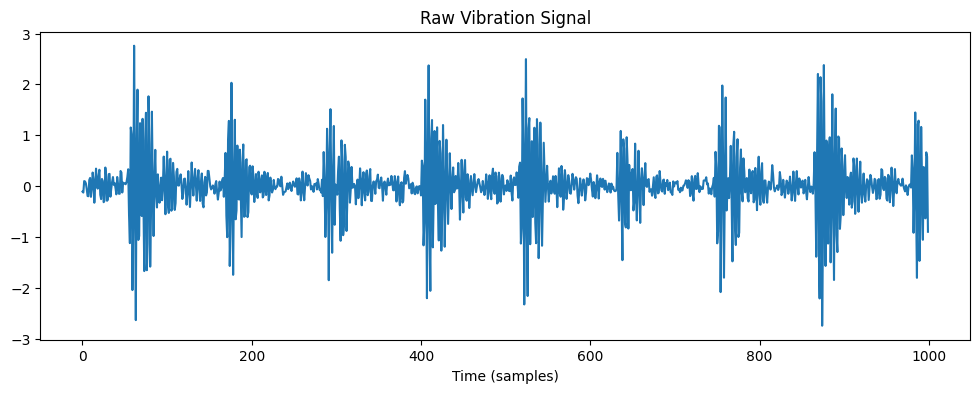

In [4]:
"""Run this cell to load the vibration data to variable called signal"""
from data_imports import import_cwru
signal, fs, fr = import_cwru() # Loads the CWRU bearing fault data into signal, fs, and fr variables
plt.figure(figsize=(12, 4))
plt.title("Raw Vibration Signal")
plt.plot(signal[:1000])
plt.xlabel("Time (samples)")

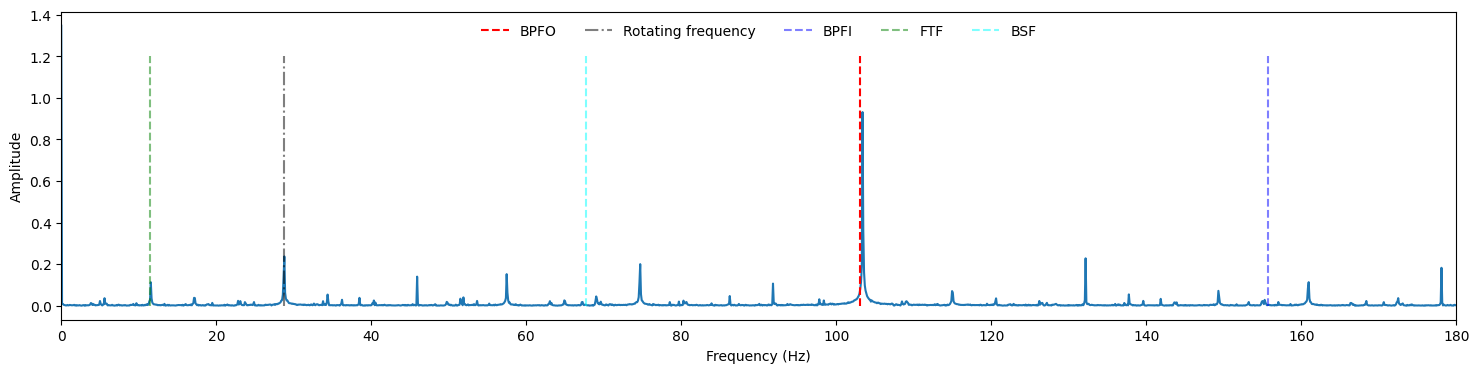

In [5]:
sq_env_f, sq_env = envelope(signal, fs) # Implement this using the previously defined envelope function

# Plot the envelope spectrum with bearing fault frequency markers
plt.figure(figsize=(18, 4))
plt.plot(sq_env_f, sq_env)
plt.xlim((0, 180))

# Mark BPFO (Ball Pass Frequency Outer Race) - primary fault indicator
plt.vlines(x=[BPFO_Hz], ymin=0, ymax=1.2, colors="r",
           linestyles="dashed", label=rf"BPFO")

# Mark rotating frequency - fundamental shaft speed
plt.vlines(x=[fr], ymin=0, ymax=1.2, colors="black",
           linestyles="-.", label=rf"Rotating frequency", alpha=0.5)

# Mark BPFI (Ball Pass Frequency Inner Race)
plt.vlines(x=[BPFI_Hz], ymin=0, ymax=1.2, colors="b",
           linestyles="dashed", label=rf"BPFI", alpha=0.5)

# Mark FTF (Fundamental Train Frequency) - cage frequency
plt.vlines(x=[FTF_Hz], ymin=0, ymax=1.2, colors="g",
           linestyles="dashed", label=rf"FTF", alpha=0.5)

# Mark BSF (Ball Spin Frequency) - rolling element defect frequency
plt.vlines(x=[BSF_Hz], ymin=0, ymax=1.2, colors="cyan",
           linestyles="dashed", label=rf"BSF", alpha=0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend(frameon=False, loc="upper center", ncol=8)

plt.show()


Which fault frequency did you identify with the envelope analysis?

You can also compare the envelope spectrum to the raw frequency transform of the signal with next code block

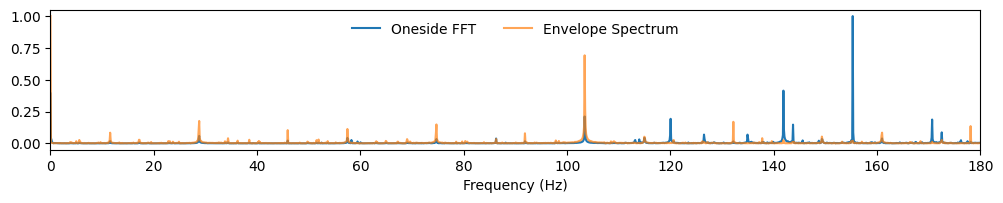

In [6]:
# For comparison of the envelope spectrum to the oneside FFT
from openconmo.utils import oneside_fft 
plt.figure(figsize=(12, 4))

# Calculates the oneside FFT of the raw signal and plot it together with the envelope spectrum using openconmo's oneside_fft function

f, X = oneside_fft(signal, fs)
plt.subplot(2,1,1)
plt.plot(f[f<180], X[f<180]/np.max(X[f<180]))
plt.plot(sq_env_f[sq_env_f<180], sq_env[sq_env_f<180]/np.max(sq_env[sq_env_f<180]), alpha=0.7);
plt.xlim((0, 180))
plt.xlabel("Frequency (Hz)")
plt.legend(["Oneside FFT", "Envelope Spectrum"], frameon=False,loc="upper center",ncols=2)

## OpenConmo demonstration

[OpenConmo](https://github.com/Aalto-Arotor/openConMo) is a Python library for vibration signal–based condition monitoring, developed at Aalto University, Finland.
The objectives of the library are:
* Provide easy access to reproducing signal based condition monitoring papers
* Enable comparison of AI/ML based techniques with conventional signal processing tools

The library is well suited also for signal processing of bearing vibration signals. It includes implementations for the envelope spectrum, [DRS](https://doi.org/10.1016/S0888-3270(03)00013-X), [Fast Kurtogram](https://doi.org/10.1016/j.ymssp.2005.12.002), [Cepstrum prewhitening](https://doi.org/10.1016/j.ymssp.2012.11.001). The next code blocks are preprogrammed for you to discover the effect of these functions. 

Envelope analysis is the core of fault diagnosis but sometimes the fault frequencies are well hidden behind other vibration sources. The DRS and kurtogram are methods designed to enhance the visibility of bearing faults.

##  Task 4. Generate synthetic vibration signal to test DRS
The block contains pre programmed synthetic signal which resembles a bearing fault scenario where the signal is corrupted with deterministic (sinusoidal) gear induced vibration as well as some electrical measurement noise.

Read the function description and generate a synthetic signal

In [7]:
def generate_synthetic_signal(
    fs=20_000,
    duration=5,
    gear_freq=80,
    f=400,
    lam=400,
    A=2,
    nominal_interval_ms=50,
    interval_jitter_ms=5,
    snr_db=15,
    random_state=None,
):
    """
    Generate a synthetic vibration signal for bearing fault studies.

    Parameters
    ----------
    fs : int, optional
        Sampling frequency in Hz. Default is 20,000.
    duration : int | float, optional
        Duration of the signal in seconds. Default is 5.
    gear_freq : int | float, optional
        Gear meshing frequency in Hz. Default is 80.
    f : int | float, optional
        Resonance frequency of bearing fault impulses in Hz. Default is 400.
    lam : int | float, optional
        Damping coefficient for impulse decay. Default is 400.
    A : int | float, optional
        Amplitude of bearing fault impulses. Default is 2.
    nominal_interval_ms : int | float, optional
        Nominal time interval between impulses in milliseconds. Default is 50.
    interval_jitter_ms : int | float, optional
        Random interval jitter around the nominal interval in milliseconds.
        Default is 5.
    snr_db : int | float, optional
        Target SNR of the final signal in dB
        Default is 15.
    random_state : int | None, optional
        Seed for reproducibility. Default is None.

    Returns
    -------
    x : ndarray
        Time vector.
    signal : ndarray
        Final synthetic vibration signal (gear + bearing fault + noise).
    gear_signal : ndarray
        Simulated deterministic gear-meshing component.
    bearing_fault_signal : ndarray
        Simulated impulsive bearing fault component.
    noise : ndarray
        Additive white Gaussian noise component.
    f_fault : float
        bearing fault frequency
    """
    if fs <= 0 or duration <= 0:
        raise ValueError("fs and duration must be positive.")
    if nominal_interval_ms <= 0:
        raise ValueError("nominal_interval_ms must be positive.")
    if interval_jitter_ms < 0:
        raise ValueError("interval_jitter_ms must be non-negative.")

    interval_min_ms = nominal_interval_ms - interval_jitter_ms
    interval_max_ms = nominal_interval_ms + interval_jitter_ms
    if interval_min_ms <= 0:
        raise ValueError("nominal_interval_ms - interval_jitter_ms must be > 0.")

    rng = np.random.default_rng(random_state)

    x = np.arange(0, duration, 1 / fs)
    total_len = len(x)

    # Convert milliseconds to samples
    interval_min = max(1, int(np.round(interval_min_ms * fs / 1000)))
    interval_max = max(interval_min, int(np.round(interval_max_ms * fs / 1000)))

    # Simplified model: impulse length follows the nominal repetition interval
    impulse_len = max(1, int(np.round(nominal_interval_ms * fs / 1000)))

    # --- 1. Gear Signal Generation ---
    harmonics = np.arange(1, 11)
    amplitudes = np.arange(1, 0, -0.1)[:, np.newaxis]
    phases = rng.uniform(0, 2 * np.pi, 10)[:, np.newaxis]

    gear_signal = np.sum(
        amplitudes * np.cos(2 * np.pi * gear_freq * harmonics[:, np.newaxis] * x + phases),
        axis=0,
    )

    # --- 2. Bearing Fault Signal Generation ---
    bearing_fault_signal = np.zeros(total_len)
    current_pos = 0

    while current_pos < total_len:
        t_impulse = np.arange(impulse_len) / fs
        tau = rng.uniform(0, 0.001)

        impulse = A * np.exp(-lam * (t_impulse + tau)) * np.sin(2 * np.pi * f * (t_impulse - tau))
        step = rng.integers(interval_min, interval_max + 1)

        end_pos = min(current_pos + impulse_len, total_len)
        actual_fill = end_pos - current_pos
        bearing_fault_signal[current_pos:end_pos] += impulse[:actual_fill]

        current_pos += step

    # --- 3. Noise & Signal Composition (SNR controlled) ---
    clean_signal = gear_signal + bearing_fault_signal

    if np.isinf(snr_db):
        noise = np.zeros_like(clean_signal)
    else:
        signal_power = np.mean(clean_signal**2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.sqrt(noise_power) * rng.normal(size=x.shape)

    signal = clean_signal + noise

    f_fault = 1 / (nominal_interval_ms * 1e-3)

    return x, signal, gear_signal, bearing_fault_signal, noise, f_fault, gear_freq


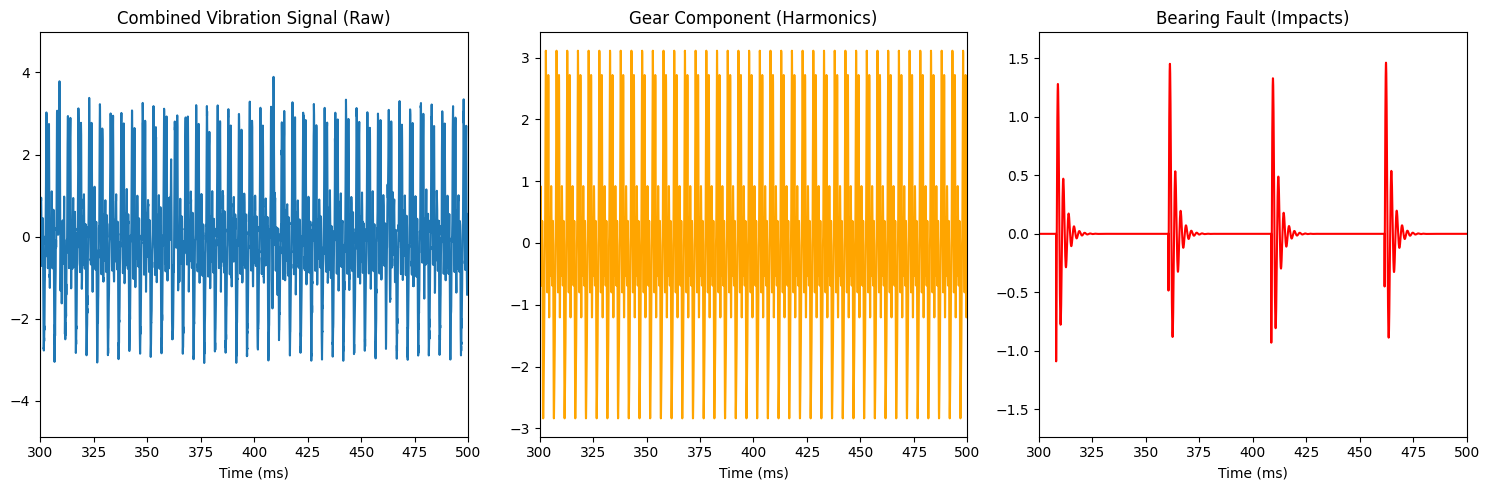

In [8]:
"""Generate the synthetic signal by running this cell. The generated signal will be stored in the variable called signal, and the time vector will be stored in x. The individual components of the signal (gear, bearing fault, noise) will also be returned for further analysis."""
fs = 20_000 # Sampling frequency in Hz
x, signal, gear_signal, bearing_fault_signal, noise, f_fault, gear_freq = generate_synthetic_signal(
    fs = fs,
    gear_freq=200,
    nominal_interval_ms=50,
    interval_jitter_ms=3,
    snr_db=20,
    A = 2
)

# --- 4. Visualization ---
plt.figure(figsize=(15, 5))

# Plotting a zoomed-in window to see the impulse shapes
zoom_range = (6_000, 10_000)

plt.subplot(1, 3, 1)
plt.plot(x*1e3, signal)
plt.xlim(zoom_range)
plt.title("Combined Vibration Signal (Raw)")
plt.xlabel("Time (ms)")
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)

plt.subplot(1, 3, 2)
plt.plot(x*1e3, gear_signal, color='orange')
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)
plt.title("Gear Component (Harmonics)")
plt.xlabel("Time (ms)")

plt.subplot(1, 3, 3)
plt.plot(x*1e3, bearing_fault_signal, color='red')
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)
plt.title("Bearing Fault (Impacts)")
plt.xlabel("Time (ms)")

plt.tight_layout()
plt.show()

## Task 5
Next your task is to apply the DRS method to previously generated signal and compare the results. 

You will notice that the DRS should be able to separate the impulses and noise from the deterministic gear signal. The reason this works is that the impulses never appear exactly at constant interval but the arrival times of the impulses are randomized.

Before trying out the DRS read through the info box about the DRS below.

## Discrete/random separation (DRS)

Rotating system have different elements such as gears, couplings and bearings which all cause vibration and corrupt the measurement. This makes distinguishing bearing damage from other components difficult in cases where the damage is minor compared to vibration originating from other components. 

Discrete/Random Separation (DRS) is a signal processing technique used to decompose a single vibration measurement into its periodic (discrete) and non-deterministic (random) components. The method exploits the fact that periodic signals remain predictable over long intervals, while broadband noise loses correlation quickly. The DRS is a method which uses the randomness of bearing fault occurrence to filter out deterministic components for example gear vibraition away from the original signal. The reason bearing signals are considered random is because of the rolling elements often slipping and not rotating with constantly. After using the DRS filter only signal from bearing fault should remain.

<figure style="text-align: center;">
  <img src="figures/drs.png" alt="DRS">
  <figcaption>DRS operates by generating a filter that estimates a time-delayed version of a data segment sweeping the whole signal. N and Delta are parameters that need to be chosen and represent the length of the segment and separation of the two segments. Typically these are chosen by trial and error. Image from [2]</figcaption>
</figure>



In [9]:
# Run this cell to import necessary functions from openconmo library
from openconmo.benchmark_methods import envelope, DRS


In [10]:
''' --- DRS Separation ---'''
## Uncomment below line to try out synthetic signals with different parameters.
## You can try to reduce the bearing fault interval jitter and see if DRS can still separate the impulses
# x, signal, gear_signal, bearing_fault_signal, noise, f_fault, gear_freq = generate_synthetic_signal(gear_freq=200, nominal_interval_ms=80, interval_jitter_ms=4, snr_db=20, A=2)


# N and Delta are variables that need to be tuned.
N = 3000      # Segment size parameter for the DRS method
Delta = 17000  # Separation delay parameter for the DRS method

# Execute the separation algorithm
random_comp, deterministic_comp = DRS(signal, N, Delta)

Building DRS filter: 100%|██████████| 770/770 [00:00<00:00, 4890.96it/s]


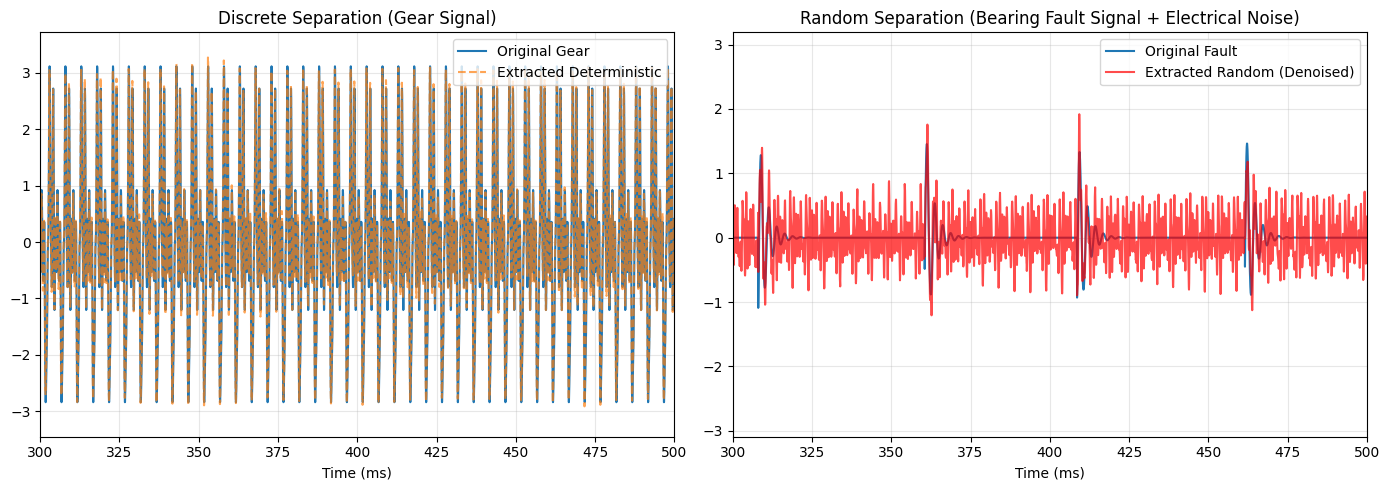

In [11]:
# --- Visualization ---
plt.figure(figsize=(14, 5))

# 1. Deterministic Component (Gearbox Harmonics)
plt.subplot(1, 2, 1)
plt.plot(x*1e3, gear_signal, label="Original Gear", linewidth=1.5)
plt.plot(x*1e3, deterministic_comp, label="Extracted Deterministic", alpha=0.7, linestyle='--')
plt.title("Discrete Separation (Gear Signal)")
plt.xlabel("Time (ms)")
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Random/Impulsive Component (Bearing Faults)
# We subtract the simulated noise to see how well the bearing 'shocks' were recovered
plt.subplot(1, 2, 2)
plt.plot(x*1e3, bearing_fault_signal, label="Original Fault", linewidth=1.5)
plt.plot(x*1e3, random_comp - noise, label="Extracted Random (Denoised)", alpha=0.7, color='red')
plt.title("Random Separation (Bearing Fault Signal + Electrical Noise)")
plt.xlabel("Time (ms)")
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As you can see the discrete frequency components are separated into the discrete/deterministic part and the randomized impulses and statistical noise is in the other signal. 

Next the envelope spectrums of the original signal and DRS filtered signal are compared. The envelope spectrum of the original signal is dominated by the gear induced vibration but the envelope spectrum from the random part of the signal shows clearly the fault frequency. Also in the envelope spectrum of the DRS random part has suppressed the gear frequencies.

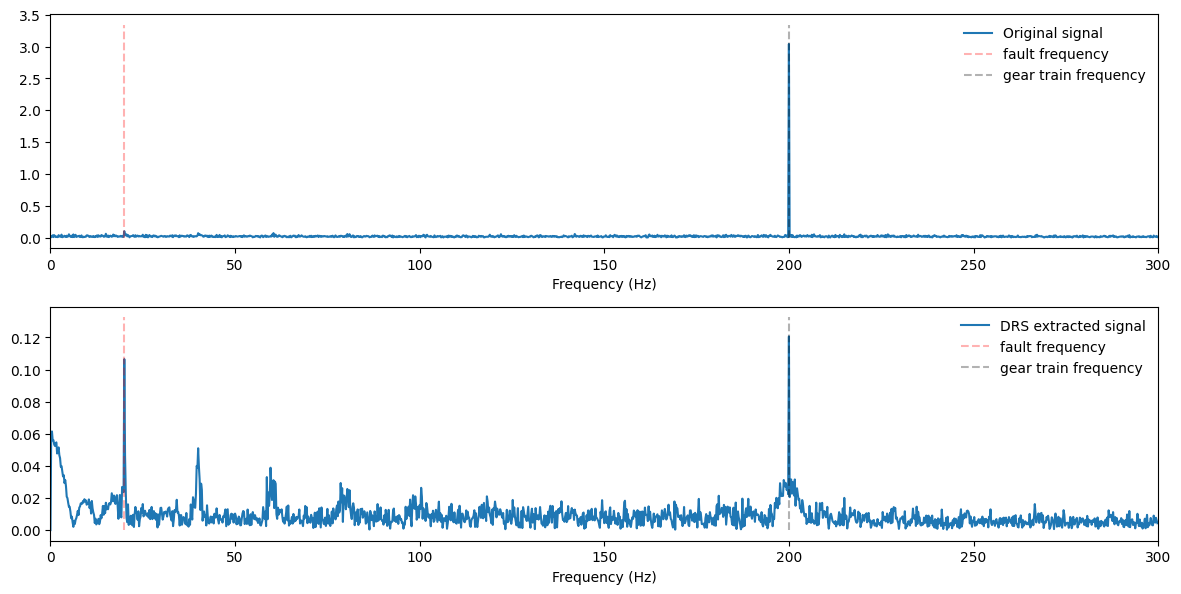

In [12]:
# Computes envelope spectra for:
# 1) original mixed signal and 2) DRS-random component (bearing-related part)
f_env, X_env = envelope(signal, 20000)
X_env[0] = 0
f_drs, X_drs = envelope(random_comp, 20000)
X_drs[0] = 0
# Expected fault repetition frequency from simulation:
fault_freq = f_fault

plt.figure(figsize=(12, 6))

# --- Top: Envelope spectrum of original signal ---
plt.subplot(2, 1, 1)
plt.plot(f_env[f_env<300], X_env[f_env<300], label="Original signal")
plt.xlim((0, 300))
# plt.yscale("log")  # Optional: log scale can reveal smaller peaks
plt.vlines(
    x=[fault_freq],
    ymin=0,
    ymax=np.max(X_env[f_env<300])*1.1,
    colors="r",
    linestyles="dashed",
    label="fault frequency",
    alpha=0.3,
)

plt.vlines(
    x=[gear_freq],
    ymin=0,
    ymax=np.max(X_env[f_env<300])*1.1,
    colors="black",
    linestyles="dashed",
    label="gear train frequency",
    alpha=0.3,
)
plt.legend(frameon=False, loc="upper right")
plt.xlabel("Frequency (Hz)")

# --- Bottom: Envelope spectrum after DRS ---
plt.subplot(2, 1, 2)
plt.plot(f_drs[f_drs<300], X_drs[f_drs<300], label="DRS extracted signal")
# plt.yscale("log")  # Optional: log scale can reveal smaller peaks
plt.vlines(
    x=[fault_freq],
    ymin=0,
    ymax=np.max(X_drs[f_drs<300])*1.1,
    colors="r",
    linestyles="dashed",
    label="fault frequency",
    alpha=0.3,
)

plt.vlines(
    x=[gear_freq],
    ymin=0,
    ymax=np.max(X_drs[f_drs<300])*1.1,
    colors="black",
    linestyles="dashed",
    label="gear train frequency",
    alpha=0.3,
)
plt.xlim((0, 300))
plt.legend(frameon=False, loc="upper right")
plt.xlabel("Frequency (Hz)")
plt.tight_layout()

As you can see the DRS together with envelope spectrum was able to diagnose the fault frequency from signal, which was dominated by a gear train vibration signal.

## Kurtosis and kurtogram band selection
Kurtosis is a value which represents the peakiness of any signal. For bearing fault diagnosis we are interested in signal components which best depict the impulses from bearing faults thus we can optimize the frequency bandwidth for kurtosis. Kurtosis is described as the fourth moment

$\text{Kurtosis} = \frac{\mu_4}{\sigma^4} = \frac{\text{E}[(X - \mu)^4]}{(\text{E}[(X - \mu)^2])^2}$

The kurtogram is spectral analysis tool designed to detect and characterize non-stationarities (transients) within a signal. It operates on the principle that different types of transients are associated with an optimal frequency band that maximizes the signal's kurtosis. By identifying the frequency band where kurtosis is highest, the kurtogram helps locate hidden non-stationary faults even when they are buried in high levels of background noise. A practical tool to find the most impulsive frequency band is the [fast kurtogram](https://doi.org/10.1016/j.ymssp.2005.12.002).

Next the kurtosis of the previously simulated signals is compared. You will notice that the random component separated by the DRS algorithm has larger kurtosis, meaning that it is more "impulsive".

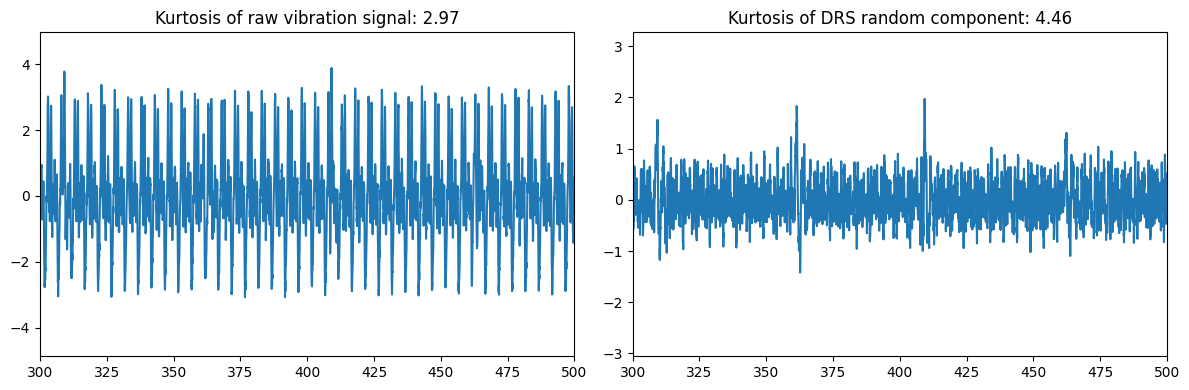

In [13]:
from scipy.stats import kurtosis  # Function to compute kurtosis

plt.figure(figsize=(12, 4))

# --- Left: Original vibration signal ---
plt.subplot(1, 2, 1)
plt.title(f"Kurtosis of raw vibration signal: {kurtosis(signal, fisher=False, bias=False):.2f}")
plt.plot(x*1e3, signal)
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)

# --- Right: DRS random component (fault-related content) ---
plt.subplot(1, 2, 2)
plt.title(f"Kurtosis of DRS random component: {kurtosis(random_comp, fisher=False, bias=False):.2f}")
plt.plot(x*1e3, random_comp)
plt.xlim(x[zoom_range[0]]*1e3, x[zoom_range[1]]*1e3)
plt.tight_layout()

The kurtosis of the DRS filtered signal is already larger than the unfiltered signal. We can further maximize the curtosis by bandpass filtering the signal. This is where we can use the fast kurtogram. Below code block imports the fast kurtogram from openconmo and by giving it our signal it automatically calculates the most impulsive band.

In [14]:
from openconmo.kurtogram import fast_kurtogram
Kwav, Level_w, freq_w, fc, bandwidth = fast_kurtogram(random_comp, fs,verbose=True, nlevel=6)


Max Level: 5.584962500721156
Freq: 0.005208333333333334
Fs: 20000
Max Kurtosis: 7.343783698640003
Center frequency: 0.10416666666666667
Bandwidth: 208.33333333333334


### The kurtogram can be visualized with openconmo function plot_kurtogram. 

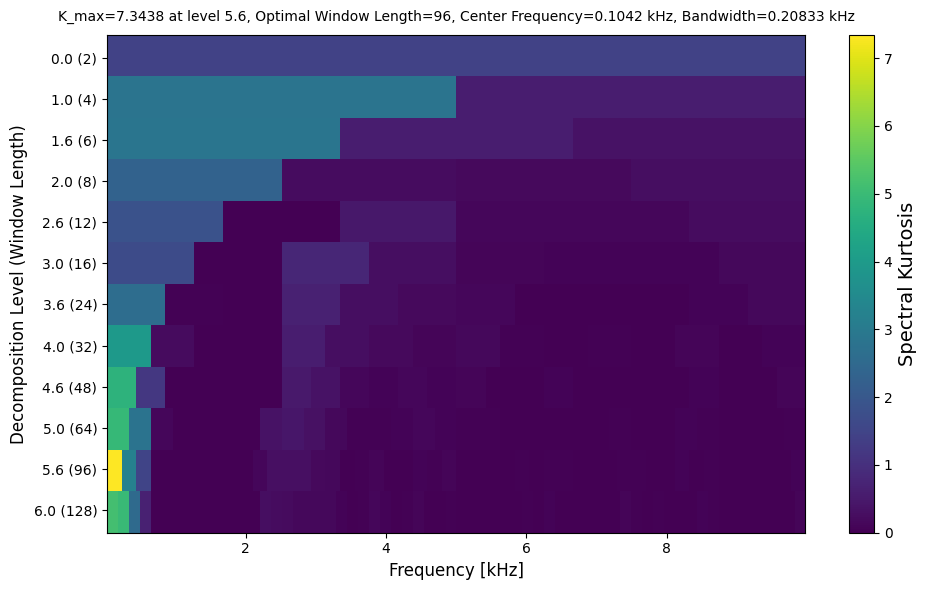

In [15]:
from openconmo.kurtogram import plot_kurtogram
plot_kurtogram(random_comp, fs,verbose=False,nlevel=6);

Applying the bandpass filter reveals the most impulsive band effectively leaving only the bearing fault signal.

Fs: 20000
Fc: 104.16666666666667
Nyquist: 10000.0
Lowcut: 1e-09
Highcut: 0.020833333333333336
signal : [-1.64542959 -1.74570235 -1.52526306 ...  0.06176401  0.3354496
  0.06021663]
kurtosis of filtered signal: 8.970808142556201


(6000.0, 8000.0)

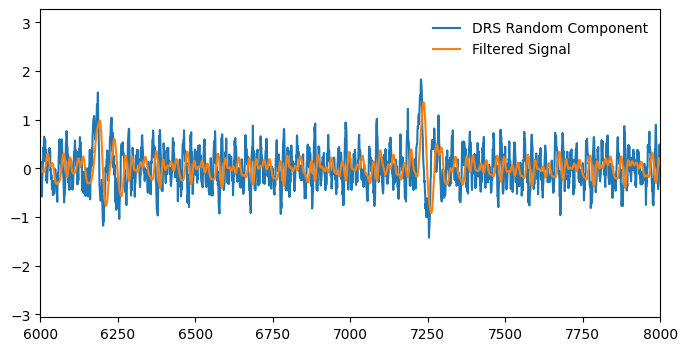

In [16]:
from openconmo.utils import bandpass_filter
filtered_signal = bandpass_filter(random_comp, fs, fc, bandwidth, order=20);
print(f"kurtosis of filtered signal:", kurtosis(filtered_signal,fisher=False, bias=False))
plt.figure(figsize=(8, 4))
plt.plot(random_comp, label="DRS Random Component")
plt.plot(filtered_signal, label="Filtered Signal")
plt.legend(frameon=False)
plt.xlim((6000, 8000))

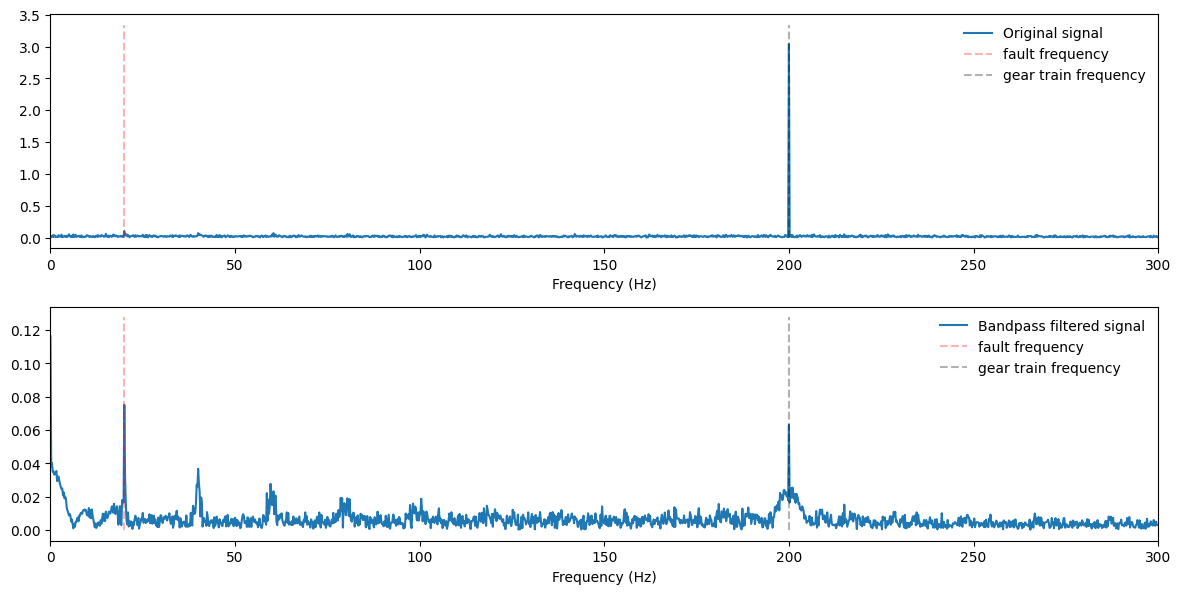

In [17]:
# Computes envelope spectra for:
# 1) original mixed signal and 2) DRS-random component (bearing-related part)
f_env, X_env = envelope(signal, fs)
X_env[0] = 0
f_bps, X_bps = envelope(filtered_signal, fs)
X_drs[0] = 0
# Expected fault repetition frequency from simulation:
fault_freq = f_fault

plt.figure(figsize=(12, 6))

# --- Top: Envelope spectrum of original signal ---
plt.subplot(2, 1, 1)
plt.plot(f_env[f_env<300], X_env[f_env<300], label="Original signal")
plt.xlim((0, 300))
# plt.yscale("log")  # Optional: log scale can reveal smaller peaks
plt.vlines(
    x=[fault_freq],
    ymin=0,
    ymax=np.max(X_env[f_env<300])*1.1,
    colors="r",
    linestyles="dashed",
    label="fault frequency",
    alpha=0.3,
)

plt.vlines(
    x=[gear_freq],
    ymin=0,
    ymax=np.max(X_env[f_env<300])*1.1,
    colors="black",
    linestyles="dashed",
    label="gear train frequency",
    alpha=0.3,
)
plt.legend(frameon=False, loc="upper right")
plt.xlabel("Frequency (Hz)")

# --- Bottom: Envelope spectrum after DRS and bandpass filtering---
plt.subplot(2, 1, 2)
plt.plot(f_bps[f_bps<300], X_bps[f_bps<300], label="Bandpass filtered signal")
# plt.yscale("log")  # Optional: log scale can reveal smaller peaks
plt.vlines(
    x=[fault_freq],
    ymin=0,
    ymax=np.max(X_bps[f_bps<300])*1.1,
    colors="r",
    linestyles="dashed",
    label="fault frequency",
    alpha=0.3,
)

plt.vlines(
    x=[gear_freq],
    ymin=0,
    ymax=np.max(X_bps[f_bps<300])*1.1,
    colors="black",
    linestyles="dashed",
    label="gear train frequency",
    alpha=0.3,
)
plt.xlim((0, 300))
plt.legend(frameon=False, loc="upper right")
plt.xlabel("Frequency (Hz)")
plt.tight_layout()

What is the effect of the bandpass filtered envelope spectrum compared to the envelope spectrum from the raw signal?

## Task 5. Perform bearing fault analysis for a certain bearing
Your task is to perform bearing fault analysis of a bearing which has been monitored using an accelerometer. Data is from [Politecnico Di Torino test rig](https://doi.org/10.5281/zenodo.13913254).

* You can use openconmo ready functions to perform the analysis
* Experiment with envelope, DRS, fast_kurtogram and bandpass filter to see which gives the best result
* Identify the fault type based on the bearing fault frequencies provided below.

| Characteristic | Frequency Value (Hz)|
| :--- | :--- |
| Ball Pass Frequency Outer Race, BPFO | $8.176 \times f_r$ |
| Ball Pass Frequency Inner Race, BPFI | $10.824 \times f_r$ |
| Ball Spin Frequency, BSF | $3.464 \times f_r$ |
| Fundamental Train Frequency, FTF | $0.43 \times f_r$ |

In [18]:
# Run this cell to import necessary functions from openconmo library
from openconmo.benchmark_methods import envelope, DRS
from openconmo.utils import bandpass_filter
from openconmo.kurtogram import fast_kurtogram, plot_kurtogram

In [19]:
# Run this cell to load vibration data
from data_imports import import_polito
signal, fs, fr = import_polito() # Loads the Politecnico di Torino bearing fault data into signal, fs, and fr variables
signal = signal-np.mean(signal)  # Remove DC offset
print(f"RPM = {fr*60}")

# Fault frequencies from above table
BPFO_Hz = 8.176 * fr 
BPFI_Hz = 10.824 * fr  
BSF_Hz = 3.464 * fr
FTF_Hz = 0.43 * fr

print(BPFO_Hz)
print(BPFI_Hz)
print(BSF_Hz)
print(FTF_Hz)

acceleration unit: [[array(['g'], dtype='<U1')]]
rpm unit: [[array(['rpm'], dtype='<U3')]]
9.54929658551379
RPM = 508.10128289341446
69.2372681489426
91.66147143397197
29.334380732379795
3.6413925274028034


Building DRS filter: 100%|██████████| 12048/12048 [00:04<00:00, 2549.91it/s]


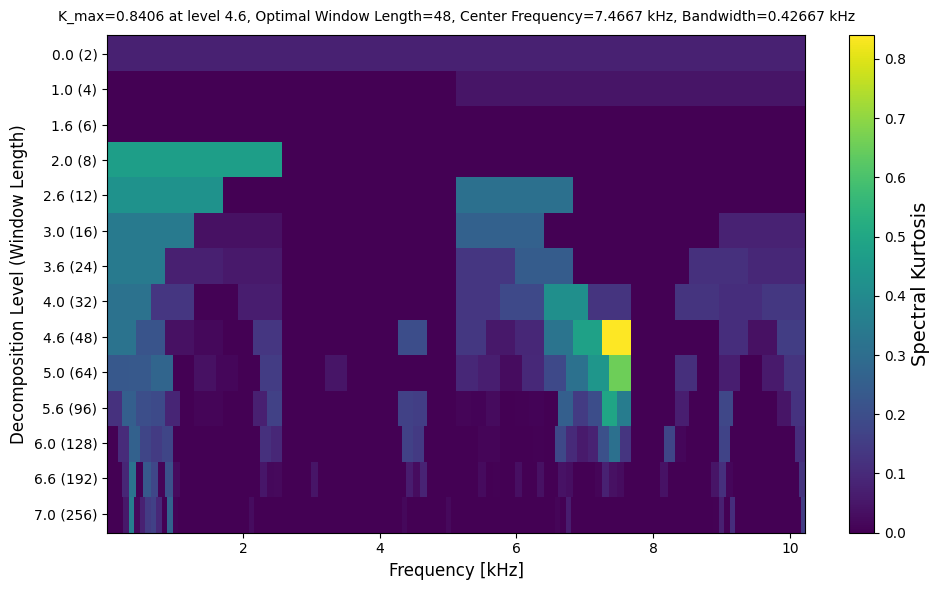

Fs: 20480.0
Fc: 1280.0
Nyquist: 10240.0
Lowcut: 1e-09
Highcut: 0.25
signal : [ 0.56620986 -0.98445456 -0.56139881 ... -0.15621653 -0.94772193
  0.61572418]


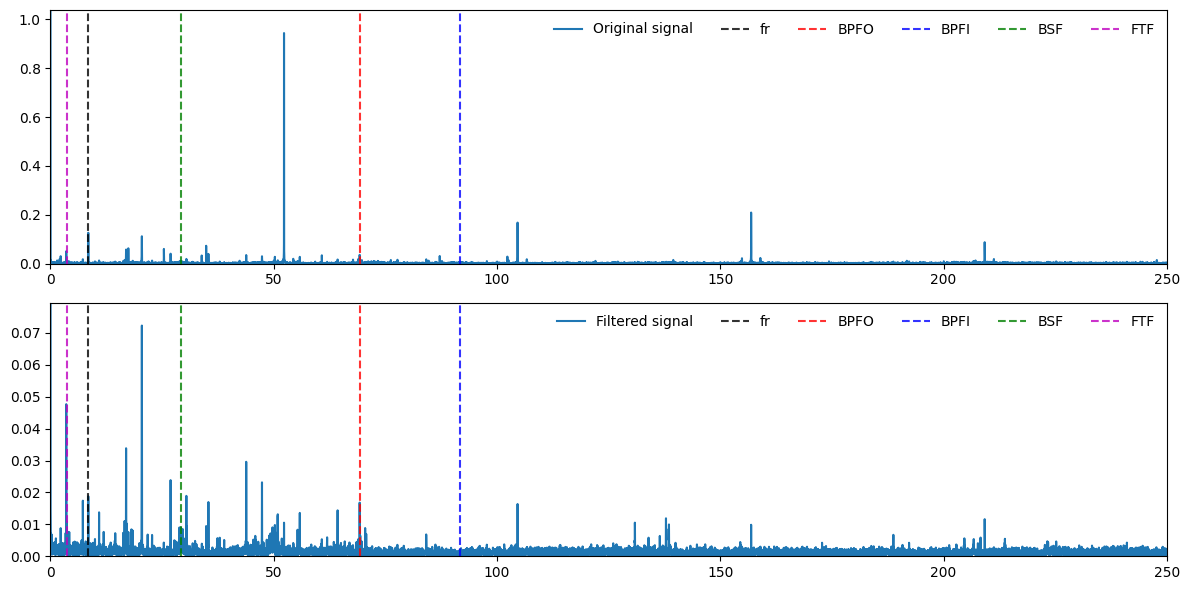

In [20]:
# Implement your code here
N = 6000
Delta = 12000
r, d = DRS(signal, N, Delta)

Kwav, Level_w, freq_w, fc, bandwidth = fast_kurtogram(r, fs, nlevel=7, verbose=False)
plot_kurtogram(signal, fs, nlevel=7, verbose=False)

filtered_signal = bandpass_filter(r, fs, fc, bandwidth, order=60)
# filtered_signal = r

# filtered_signal = cepstrum_prewhitening(filtered_signal, fs)



plt.figure(figsize=(12, 6))

fault_lines = [
    (fr, "fr", "k"),
    (BPFO_Hz, "BPFO", "r"),
    (BPFI_Hz, "BPFI", "b"),
    (BSF_Hz, "BSF", "g"),
    (FTF_Hz, "FTF", "m"),
]

plt.subplot(2, 1, 1)
f, X = envelope(signal, fs)
plt.plot(f, X, label="Original signal")
for freq, label, color in fault_lines:
    plt.axvline(freq, linestyle="--", color=color, alpha=0.8, label=label)
plt.xlim((0, 250))
plt.legend(frameon=False, ncol=6)
mask = (f > 1) & (f < 100)
plt.ylim((0, np.max(X[mask]) * 1.1))
# plt.yscale("log")

plt.subplot(2, 1, 2)
f, X = envelope(filtered_signal, fs)
plt.plot(f, X, label="Filtered signal")
for freq, label, color in fault_lines:
    plt.axvline(freq, linestyle="--", color=color, alpha=0.8, label=label)
plt.xlim((0, 250))
plt.legend(frameon=False, ncol=6,loc="upper right")
mask = (f > 1) & (f < 100)
plt.ylim((0, np.max(X[mask]) * 1.1))
# plt.yscale("log")


plt.tight_layout()


## Sources
[1] Chenyu Liu, Alexandre Mauricio, Junyu Qi, Dandan Peng, and Konstantinos
Gryllias. Domain Adaptation Digital Twin for Rolling Element Bearing Prog-
nostics. Annual Conference of the PHM Society, 12(1):10, November 2020.
doi:10.36001/phmconf.2020.v12i1.1294.

[2] Antoni, J., & Randall, R. B. (2004). Unsupervised noise cancellation for vibration signals: part II—a novel frequency-domain algorithm. Mechanical systems and signal processing, 18(1), 103-117.]